In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [15]:
import os

plots_dir = "plots"
if not os.path.exists(plots_dir):
    os.makedirs(plots_dir)  


mcmcfit_dir = "mcmc_fits"
if not os.path.exists(mcmcfit_dir):
    os.makedirs(mcmcfit_dir)

In [2]:
df = pd.read_csv('GaiaParallax/TotalAvg_Good_Single_Fits_s_0.33_level_0.csv')
pd.set_option('display.max_columns', None)
df

,Latitude,Long,Mean Parallax,Mean Parallax Error,Weighted Mean Parallax,Parallax Median,Parallax Mode,Parallax Dispersion,Parallax Clip Fraction,Number at parallax mean,Mean Magnitude,Magnitude Dispersion,Number at Mag mean,Mean Color,Color Dispersion,Number at color mean,Count,Magnitude Distinctness,D1Mag Distinctness,D2Mag Distinctness,Double Clump width,Color Distinctness,Distance Modulus,Red Clump Fraction,Red Clump Width,Red Clump 1 Width,Red Clump 2 Width,Most Common Pixel
0,3.24,-7.59,0.137810,0.010143,0.133054,0.132097,0.089206,0.155092,0.808362,21.768656,17.470576,0.381450,101.955698,2.341623,0.143782,54.336192,373.0,1.120574,1.017798,0.091949,0.143034,3.182912,-0.696403,0.335733,0.376791,17.847757,17.781668,10.0
1,3.24,-7.59,0.137810,0.010143,0.133054,0.132097,0.089206,0.155092,0.808362,21.768656,17.470576,0.381450,101.955698,2.341623,0.143782,54.336192,373.0,1.120574,1.017798,0.091949,0.143034,3.182912,-0.696403,0.335733,0.376791,17.847757,17.781668,10.0
2,3.24,-7.59,0.137810,0.010143,0.133054,0.132097,0.089206,0.155092,0.808362,21.768656,17.470576,0.381450,101.955698,2.341623,0.143782,54.336192,373.0,1.120574,1.017798,0.091949,0.143034,3.182912,-0.696403,0.335733,0.376791,17.847757,17.781668,10.0
3,3.24,-7.59,0.137810,0.010143,0.133054,0.132097,0.089206,0.155092,0.808362,21.768656,17.470576,0.381450,101.955698,2.341623,0.143782,54.336192,373.0,1.120574,1.017798,0.091949,0.143034,3.182912,-0.696403,0.335733,0.376791,17.847757,17.781668,10.0
4,3.24,-7.59,0.137810,0.010143,0.133054,0.132097,0.089206,0.155092,0.808362,21.768656,17.470576,0.381450,101.955698,2.341623,0.143782,54.336192,373.0,1.120574,1.017798,0.091949,0.143034,3.182912,-0.696403,0.335733,0.376791,17.847757,17.781668,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7620,4.89,7.59,0.150356,0.005775,0.150931,0.146367,0.107128,0.083155,0.816934,10.472440,16.451755,0.445358,120.154007,1.978805,0.128609,41.180150,270.0,1.642253,1.185246,0.336825,0.612594,9.488025,-0.885600,0.414611,0.442989,16.613518,17.150893,7.0
7621,4.89,7.92,0.149599,0.006053,0.152355,0.153188,0.190340,0.077293,0.799098,8.064060,16.504157,0.349301,113.382288,1.991464,0.145093,58.767998,227.0,1.278484,4.559427,8.973797,1.102157,9191.094041,-0.874099,0.369580,0.345987,16.738788,18.071509,7.0
7622,4.89,8.25,0.133159,0.009698,0.134390,0.131414,0.072859,0.123780,0.802198,12.610093,17.052443,0.404987,168.765163,2.276755,0.108375,32.808653,234.0,1.332008,-9.629539,-3.084131,1.009333,9.838492,-0.621851,0.372230,0.402656,17.851746,18.345555,7.0
7623,4.89,8.58,0.158702,0.011303,0.158592,0.163986,0.180814,0.124892,0.864780,11.066312,17.230605,0.430780,77.609552,2.388219,0.111271,29.476343,232.0,1.060674,6.005857,16.602298,0.432525,5.282719,-1.002916,0.315831,0.426442,16.878839,17.678824,7.0


In [3]:
# Check which rows are duplicates (returns boolean Series)
print(df.duplicated())

# Get all duplicate rows
display(df[df.duplicated()])

# Check duplicates including first occurrence
display(df[df.duplicated(keep=False)])

# Count number of duplicates
print(df.duplicated().sum())



0       False
1        True
2        True
3        True
4        True
        ...  
7620     True
7621     True
7622     True
7623     True
7624     True
Length: 7625, dtype: bool


,Latitude,Long,Mean Parallax,Mean Parallax Error,Weighted Mean Parallax,Parallax Median,Parallax Mode,Parallax Dispersion,Parallax Clip Fraction,Number at parallax mean,Mean Magnitude,Magnitude Dispersion,Number at Mag mean,Mean Color,Color Dispersion,Number at color mean,Count,Magnitude Distinctness,D1Mag Distinctness,D2Mag Distinctness,Double Clump width,Color Distinctness,Distance Modulus,Red Clump Fraction,Red Clump Width,Red Clump 1 Width,Red Clump 2 Width,Most Common Pixel
1,3.24,-7.59,0.137810,0.010143,0.133054,0.132097,0.089206,0.155092,0.808362,21.768656,17.470576,0.381450,101.955698,2.341623,0.143782,54.336192,373.0,1.120574,1.017798,0.091949,0.143034,3.182912,-0.696403,0.335733,0.376791,17.847757,17.781668,10.0
2,3.24,-7.59,0.137810,0.010143,0.133054,0.132097,0.089206,0.155092,0.808362,21.768656,17.470576,0.381450,101.955698,2.341623,0.143782,54.336192,373.0,1.120574,1.017798,0.091949,0.143034,3.182912,-0.696403,0.335733,0.376791,17.847757,17.781668,10.0
3,3.24,-7.59,0.137810,0.010143,0.133054,0.132097,0.089206,0.155092,0.808362,21.768656,17.470576,0.381450,101.955698,2.341623,0.143782,54.336192,373.0,1.120574,1.017798,0.091949,0.143034,3.182912,-0.696403,0.335733,0.376791,17.847757,17.781668,10.0
4,3.24,-7.59,0.137810,0.010143,0.133054,0.132097,0.089206,0.155092,0.808362,21.768656,17.470576,0.381450,101.955698,2.341623,0.143782,54.336192,373.0,1.120574,1.017798,0.091949,0.143034,3.182912,-0.696403,0.335733,0.376791,17.847757,17.781668,10.0
5,3.24,-7.59,0.137810,0.010143,0.133054,0.132097,0.089206,0.155092,0.808362,21.768656,17.470576,0.381450,101.955698,2.341623,0.143782,54.336192,373.0,1.120574,1.017798,0.091949,0.143034,3.182912,-0.696403,0.335733,0.376791,17.847757,17.781668,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7620,4.89,7.59,0.150356,0.005775,0.150931,0.146367,0.107128,0.083155,0.816934,10.472440,16.451755,0.445358,120.154007,1.978805,0.128609,41.180150,270.0,1.642253,1.185246,0.336825,0.612594,9.488025,-0.885600,0.414611,0.442989,16.613518,17.150893,7.0
7621,4.89,7.92,0.149599,0.006053,0.152355,0.153188,0.190340,0.077293,0.799098,8.064060,16.504157,0.349301,113.382288,1.991464,0.145093,58.767998,227.0,1.278484,4.559427,8.973797,1.102157,9191.094041,-0.874099,0.369580,0.345987,16.738788,18.071509,7.0
7622,4.89,8.25,0.133159,0.009698,0.134390,0.131414,0.072859,0.123780,0.802198,12.610093,17.052443,0.404987,168.765163,2.276755,0.108375,32.808653,234.0,1.332008,-9.629539,-3.084131,1.009333,9.838492,-0.621851,0.372230,0.402656,17.851746,18.345555,7.0
7623,4.89,8.58,0.158702,0.011303,0.158592,0.163986,0.180814,0.124892,0.864780,11.066312,17.230605,0.430780,77.609552,2.388219,0.111271,29.476343,232.0,1.060674,6.005857,16.602298,0.432525,5.282719,-1.002916,0.315831,0.426442,16.878839,17.678824,7.0


,Latitude,Long,Mean Parallax,Mean Parallax Error,Weighted Mean Parallax,Parallax Median,Parallax Mode,Parallax Dispersion,Parallax Clip Fraction,Number at parallax mean,Mean Magnitude,Magnitude Dispersion,Number at Mag mean,Mean Color,Color Dispersion,Number at color mean,Count,Magnitude Distinctness,D1Mag Distinctness,D2Mag Distinctness,Double Clump width,Color Distinctness,Distance Modulus,Red Clump Fraction,Red Clump Width,Red Clump 1 Width,Red Clump 2 Width,Most Common Pixel
0,3.24,-7.59,0.137810,0.010143,0.133054,0.132097,0.089206,0.155092,0.808362,21.768656,17.470576,0.381450,101.955698,2.341623,0.143782,54.336192,373.0,1.120574,1.017798,0.091949,0.143034,3.182912,-0.696403,0.335733,0.376791,17.847757,17.781668,10.0
1,3.24,-7.59,0.137810,0.010143,0.133054,0.132097,0.089206,0.155092,0.808362,21.768656,17.470576,0.381450,101.955698,2.341623,0.143782,54.336192,373.0,1.120574,1.017798,0.091949,0.143034,3.182912,-0.696403,0.335733,0.376791,17.847757,17.781668,10.0
2,3.24,-7.59,0.137810,0.010143,0.133054,0.132097,0.089206,0.155092,0.808362,21.768656,17.470576,0.381450,101.955698,2.341623,0.143782,54.336192,373.0,1.120574,1.017798,0.091949,0.143034,3.182912,-0.696403,0.335733,0.376791,17.847757,17.781668,10.0
3,3.24,-7.59,0.137810,0.010143,0.133054,0.132097,0.089206,0.155092,0.808362,21.768656,17.470576,0.381450,101.955698,2.341623,0.143782,54.336192,373.0,1.120574,1.017798,0.091949,0.143034,3.182912,-0.696403,0.335733,0.376791,17.847757,17.781668,10.0
4,3.24,-7.59,0.137810,0.010143,0.133054,0.132097,0.089206,0.155092,0.808362,21.768656,17.470576,0.381450,101.955698,2.341623,0.143782,54.336192,373.0,1.120574,1.017798,0.091949,0.143034,3.182912,-0.696403,0.335733,0.376791,17.847757,17.781668,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7620,4.89,7.59,0.150356,0.005775,0.150931,0.146367,0.107128,0.083155,0.816934,10.472440,16.451755,0.445358,120.154007,1.978805,0.128609,41.180150,270.0,1.642253,1.185246,0.336825,0.612594,9.488025,-0.885600,0.414611,0.442989,16.613518,17.150893,7.0
7621,4.89,7.92,0.149599,0.006053,0.152355,0.153188,0.190340,0.077293,0.799098,8.064060,16.504157,0.349301,113.382288,1.991464,0.145093,58.767998,227.0,1.278484,4.559427,8.973797,1.102157,9191.094041,-0.874099,0.369580,0.345987,16.738788,18.071509,7.0
7622,4.89,8.25,0.133159,0.009698,0.134390,0.131414,0.072859,0.123780,0.802198,12.610093,17.052443,0.404987,168.765163,2.276755,0.108375,32.808653,234.0,1.332008,-9.629539,-3.084131,1.009333,9.838492,-0.621851,0.372230,0.402656,17.851746,18.345555,7.0
7623,4.89,8.58,0.158702,0.011303,0.158592,0.163986,0.180814,0.124892,0.864780,11.066312,17.230605,0.430780,77.609552,2.388219,0.111271,29.476343,232.0,1.060674,6.005857,16.602298,0.432525,5.282719,-1.002916,0.315831,0.426442,16.878839,17.678824,7.0


7374


In [4]:
df.drop_duplicates()  # Keep first occurrence
df_u = df.drop_duplicates(keep='last')  # Keep last occurrence
display(df_u)

,Latitude,Long,Mean Parallax,Mean Parallax Error,Weighted Mean Parallax,Parallax Median,Parallax Mode,Parallax Dispersion,Parallax Clip Fraction,Number at parallax mean,Mean Magnitude,Magnitude Dispersion,Number at Mag mean,Mean Color,Color Dispersion,Number at color mean,Count,Magnitude Distinctness,D1Mag Distinctness,D2Mag Distinctness,Double Clump width,Color Distinctness,Distance Modulus,Red Clump Fraction,Red Clump Width,Red Clump 1 Width,Red Clump 2 Width,Most Common Pixel
788,3.24,-7.59,0.137810,0.010143,0.133054,0.132097,0.089206,0.155092,0.808362,21.768656,17.470576,0.381450,101.955698,2.341623,0.143782,54.336192,373.0,1.120574,1.017798,0.091949,0.143034,3.182912,-0.696403,0.335733,0.376791,17.847757,17.781668,10.0
789,3.24,-5.94,0.119154,0.007858,0.121181,0.121323,0.079289,0.166700,0.803352,33.650484,17.788205,0.387728,342.954435,2.511629,0.142046,57.459491,537.0,1.399461,0.517191,9.139551,0.204322,5.812561,-0.380535,0.393697,0.387289,17.677066,18.233791,10.0
790,3.24,-5.61,0.115977,0.011080,0.121422,0.118198,0.118288,0.254980,0.818942,62.045158,18.283263,0.446369,326.265160,2.803826,0.223817,103.274472,666.0,1.085642,7.854018,3.616284,0.509829,12.465648,-0.321856,0.321573,0.446001,18.702778,18.826129,10.0
791,3.24,-3.96,0.137534,0.011306,0.133482,0.122569,0.123544,0.248097,0.845489,58.641768,18.282348,0.312465,99.848449,2.948182,0.183353,86.428558,680.0,1.149467,1.707519,4.943646,0.961817,8.244977,-0.692055,0.345037,0.311947,17.829859,18.630048,7.0
792,3.24,-3.63,0.159193,0.011185,0.158373,0.168971,0.197637,0.256422,0.828877,59.602998,17.776824,0.310918,112.175397,2.601213,0.169336,83.455778,708.0,1.466623,0.889330,25.294053,0.531586,11.733527,-1.009615,0.406677,0.310222,17.274685,18.078229,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7620,4.89,7.59,0.150356,0.005775,0.150931,0.146367,0.107128,0.083155,0.816934,10.472440,16.451755,0.445358,120.154007,1.978805,0.128609,41.180150,270.0,1.642253,1.185246,0.336825,0.612594,9.488025,-0.885600,0.414611,0.442989,16.613518,17.150893,7.0
7621,4.89,7.92,0.149599,0.006053,0.152355,0.153188,0.190340,0.077293,0.799098,8.064060,16.504157,0.349301,113.382288,1.991464,0.145093,58.767998,227.0,1.278484,4.559427,8.973797,1.102157,9191.094041,-0.874099,0.369580,0.345987,16.738788,18.071509,7.0
7622,4.89,8.25,0.133159,0.009698,0.134390,0.131414,0.072859,0.123780,0.802198,12.610093,17.052443,0.404987,168.765163,2.276755,0.108375,32.808653,234.0,1.332008,-9.629539,-3.084131,1.009333,9.838492,-0.621851,0.372230,0.402656,17.851746,18.345555,7.0
7623,4.89,8.58,0.158702,0.011303,0.158592,0.163986,0.180814,0.124892,0.864780,11.066312,17.230605,0.430780,77.609552,2.388219,0.111271,29.476343,232.0,1.060674,6.005857,16.602298,0.432525,5.282719,-1.002916,0.315831,0.426442,16.878839,17.678824,7.0


In [5]:
#choose unique latitudes
unique_latitudes = df['Latitude'].unique()
print(unique_latitudes, len(unique_latitudes))
unique_longitudes = df['Long'].unique()
print(unique_longitudes, len(unique_longitudes))
print(6*58)

[3.24 3.57 3.9  4.23 4.56 4.89] 6
[-7.59 -5.94 -5.61 -3.96 -3.63 -3.3  -2.97 -2.64 -1.98 -1.65 -1.32 -0.99
 -0.66 -0.33  0.33  2.97  3.3   3.63  3.96  4.29  4.62  4.95  5.28  5.61
  5.94  6.27  6.93  7.26  7.59  8.25  8.58  9.57 -9.24 -8.25 -7.26 -6.6
 -6.27 -4.95 -4.62 -4.29 -2.31  2.31  2.64  6.6   7.92  8.91 -9.9  -8.58
 -7.92 -6.93 -5.28  1.98 -8.91  0.66  0.99  1.32  1.65  9.24] 58
348


/var/folders/8l/p90_cj915l7dtkqz4wc5w59r0000gn/T/ipykernel_12243/3613413662.py:26: RuntimeWarning: divide by zero encountered in divide
  axsec = ax.secondary_yaxis('right', functions=(lambda x: 1/x, lambda x: 1/x))


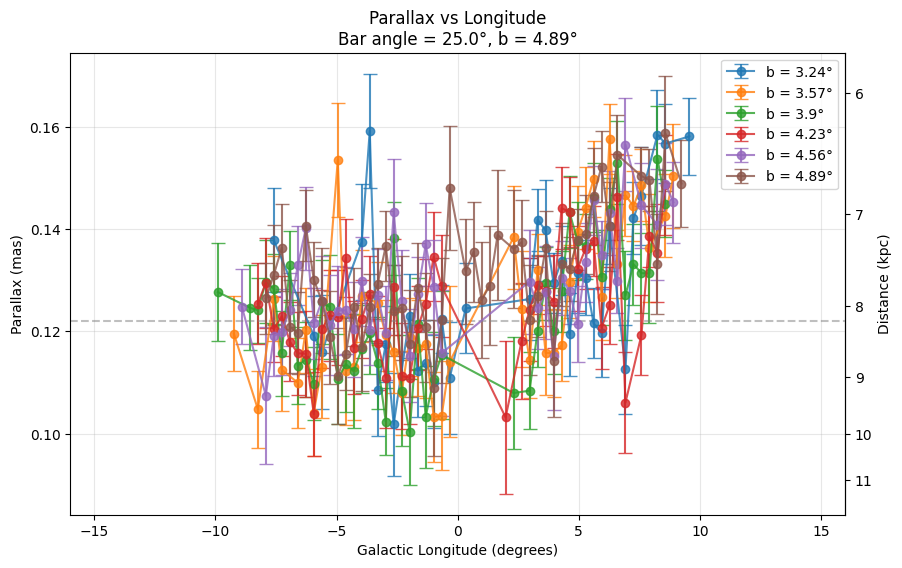

In [14]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)

for fixed_b_deg in unique_latitudes:
    df_u_lat = df_u[df_u['Latitude'] == fixed_b_deg]


    longitude_range = df_u_lat['Long']
    parallax_data = df_u_lat['Mean Parallax']
    parallax_error = df_u_lat['Mean Parallax Error']

    ax.errorbar(longitude_range, parallax_data, 
                yerr=parallax_error, 
                fmt='o-', alpha=0.8,
                capsize=5, markersize=6, label=f'b = {fixed_b_deg}°')
    #ax.plot(longitude_range, analytic_parallaxes, 
    #        's--', color='blue', alpha=0.7, label='Analytic Model', markersize=6)
ax.set_xlabel('Galactic Longitude (degrees)')
ax.set_ylabel(f'Parallax (mas)')
ax.set_title(f'Parallax vs Longitude\nBar angle = {fixed_bar_angle}°, b = {fixed_b_deg}°')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlim(-16, 16)
ax.axhline(1/8.2, color='gray', linestyle='--', alpha=0.5)

axsec = ax.secondary_yaxis('right', functions=(lambda x: 1/x, lambda x: 1/x))
axsec.set_ylabel('Distance (kpc)')

fig.savefig(os.path.join(plots_dir, f'GaiaDR3_parallax_vs_longitude.png'), dpi=300)
plt.show()

# Focused run:

- For each strip of b:
    - run mcmc with priors on all except bar angle
    - run mcmc without priors except rE and sigma_z
    
- For all b values together:
    - run mcmc with priors on all except bar angle
    - run mcmc without priors except rE and sigma_z
    - run mcmc without priors except rE


In [ ]:
from bar_angle_fitter import BarAngleFitter

model_params = {
    'sigma_x': {'mean': 0.67, 'std': 0.1},
    'sigma_y': {'mean': 0.29, 'std': 0.05},
    'sigma_z': {'mean': 0.27, 'std': 0.05},
    'r_E': {'mean': 8.2, 'std': 0.2},
    's_max': 15.0  # Always fixed
}

for fixed_b_deg in unique_latitudes:
    df_u_lat = df_u[df_u['Latitude'] == fixed_b_deg]


    longitude_range = df_u_lat['Long']
    parallax_data = df_u_lat['Mean Parallax']
    parallax_error = df_u_lat['Mean Parallax Error']

    fitter = BarAngleFitter(
        parallax_data=parallax_data,
        parallax_error=parallax_error,
        l_values=longitude_range,
        b_values=fixed_b_deg,
        model_params=model_params,
        fit_params=['bar_angle', 'zp', 'sigma_x', 'sigma_y', 'sigma_z', 'r_E']
    )

    # Run MCMC
    samples = fitter.run_mcmc(n_walkers=12, n_steps=2000, n_burn=100)
    # save MCMC samples
    np.save(os.path.join(mcmcfit_dir, f'AllPriors_MCMCsamples_b_{fixed_b_deg:.2f}.npy'), samples)


In [ ]:
from bar_angle_fitter import BarAngleFitter

model_params = {
    'sigma_x': 0.67,
    'sigma_y': 0.29,
    'sigma_z': {'mean': 0.27, 'std': 0.05},
    'r_E': {'mean': 8.2, 'std': 0.2},
    's_max': 15.0  # Always fixed
}

for fixed_b_deg in unique_latitudes:
    df_u_lat = df_u[df_u['Latitude'] == fixed_b_deg]


    longitude_range = df_u_lat['Long']
    parallax_data = df_u_lat['Mean Parallax']
    parallax_error = df_u_lat['Mean Parallax Error']

    fitter = BarAngleFitter(
        parallax_data=parallax_data,
        parallax_error=parallax_error,
        l_values=longitude_range,
        b_values=fixed_b_deg,
        model_params=model_params,
        fit_params=['bar_angle', 'zp', 'sigma_x', 'sigma_y', 'sigma_z', 'r_E']
    )

    # Run MCMC
    samples = fitter.run_mcmc(n_walkers=12, n_steps=2000, n_burn=100, priors_range={'sigma_x': (0.4, 1.1), 'sigma_y': (0.1, 0.5)})
    # save MCMC samples
    np.save(os.path.join(mcmcfit_dir, f'sigZrEPriors_MCMCsamples_b_{fixed_b_deg:.2f}.npy'), samples)


In [ ]:
from bar_angle_fitter import BarAngleFitter
model_params = {
    'sigma_x': {'mean': 0.67, 'std': 0.1},
    'sigma_y': {'mean': 0.29, 'std': 0.05},
    'sigma_z': {'mean': 0.27, 'std': 0.05},
    'r_E': {'mean': 8.2, 'std': 0.2},
    's_max': 15.0  # Always fixed
}

longitude_range = df_u['Long']
latitude_range = df_u['Latitude']
parallax_data = df_u['Mean Parallax']
parallax_error = df_u['Mean Parallax Error']


fitter = BarAngleFitter(
    parallax_data=parallax_data,
    parallax_error=parallax_error,
    l_values=longitude_range,
    b_values=latitude_range,
    model_params=model_params,
    fit_params=['bar_angle', 'zp', 'sigma_x', 'sigma_y', 'sigma_z', 'r_E']
)

# Run MCMC
fitter.run_mcmc(n_walkers=12, n_steps=2000, n_burn=100)
# save MCMC samples
np.save(os.path.join(mcmcfit_dir, f'AllPriors_MCMCsamples_all_b.npy'), fitter.samples)


In [ ]:
from bar_angle_fitter import BarAngleFitter

model_params = {
    'sigma_x': 0.67,
    'sigma_y': 0.29,
    'sigma_z': {'mean': 0.27, 'std': 0.05},
    'r_E': {'mean': 8.2, 'std': 0.2},
    's_max': 15.0  # Always fixed
}
longitude_range = df_u['Long']
latitude_range = df_u['Latitude']
parallax_data = df_u['Mean Parallax']
parallax_error = df_u['Mean Parallax Error']


fitter = BarAngleFitter(
    parallax_data=parallax_data,
    parallax_error=parallax_error,
    l_values=longitude_range,
    b_values=latitude_range,
    model_params=model_params,
    fit_params=['bar_angle', 'zp', 'sigma_x', 'sigma_y', 'sigma_z', 'r_E']
)

# Run MCMC
fitter.run_mcmc(n_walkers=12, n_steps=2000, n_burn=100, priors_range={'sigma_x': (0.4, 1.1), 'sigma_y': (0.1, 0.5)})
# save MCMC samples
np.save(os.path.join(mcmcfit_dir, f'sigZrEPriors_MCMCsamples_all_b.npy'), fitter.samples)


In [ ]:
from bar_angle_fitter import BarAngleFitter

model_params = {
    'sigma_x': 0.67,
    'sigma_y': 0.29,
    'sigma_z': 0.27,
    'r_E': {'mean': 8.2, 'std': 0.2},
    's_max': 15.0  # Always fixed
}
longitude_range = df_u['Long']
latitude_range = df_u['Latitude']
parallax_data = df_u['Mean Parallax']
parallax_error = df_u['Mean Parallax Error']


fitter = BarAngleFitter(
    parallax_data=parallax_data,
    parallax_error=parallax_error,
    l_values=longitude_range,
    b_values=latitude_range,
    model_params=model_params,
    fit_params=['bar_angle', 'zp', 'sigma_x', 'sigma_y', 'sigma_z', 'r_E']
)

# Run MCMC
fitter.run_mcmc(n_walkers=12, n_steps=2000, n_burn=100, priors_range={'sigma_x': (0.4, 1.1), 'sigma_y': (0.1, 0.5), 'sigma_z': (0.2, 0.4)})
# save MCMC samples
np.save(os.path.join(mcmcfit_dir, f'rEPriors_MCMCsamples_all_b.npy'), fitter.samples)


In [ ]:



# Plot all results (chains, corner plot, fit)

fitter.plot_results(truths=[25.0, 0.0, 0.67, 0.29, 0.27, 8.2])
# Get numerical results
results = fitter.get_results()
print(f"Bar angle: {results['bar_angle']['median']:.2f}° $\\pm$ {results['bar_angle']['std']:.2f}°")
print(f"Zero-point: {results['zp']['median']:.4f} $\\pm$ {results['zp']['std']:.4f} mas")

100%|██████████| 2000/2000 [09:54<00:00,  3.37it/s]


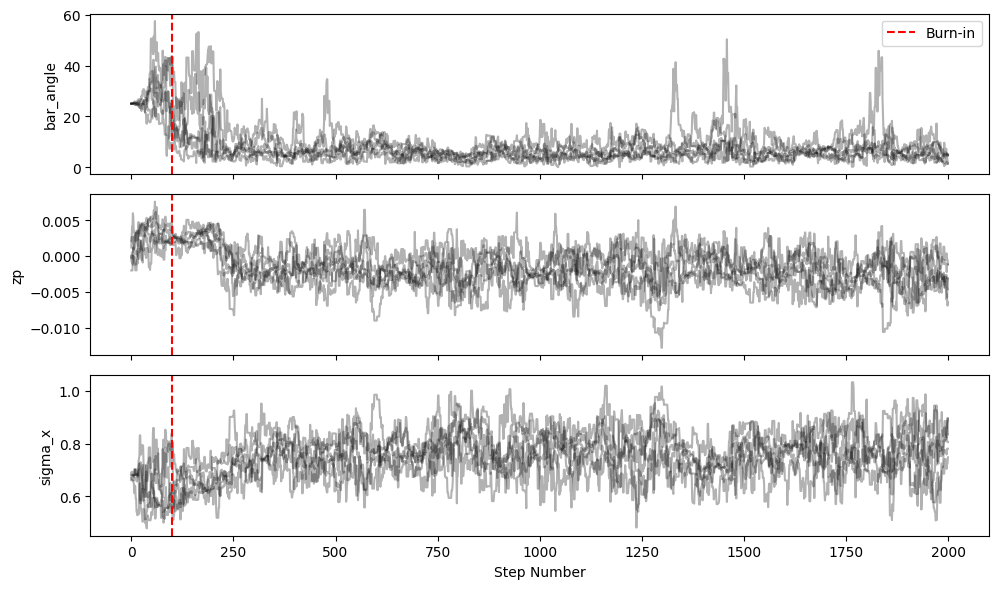

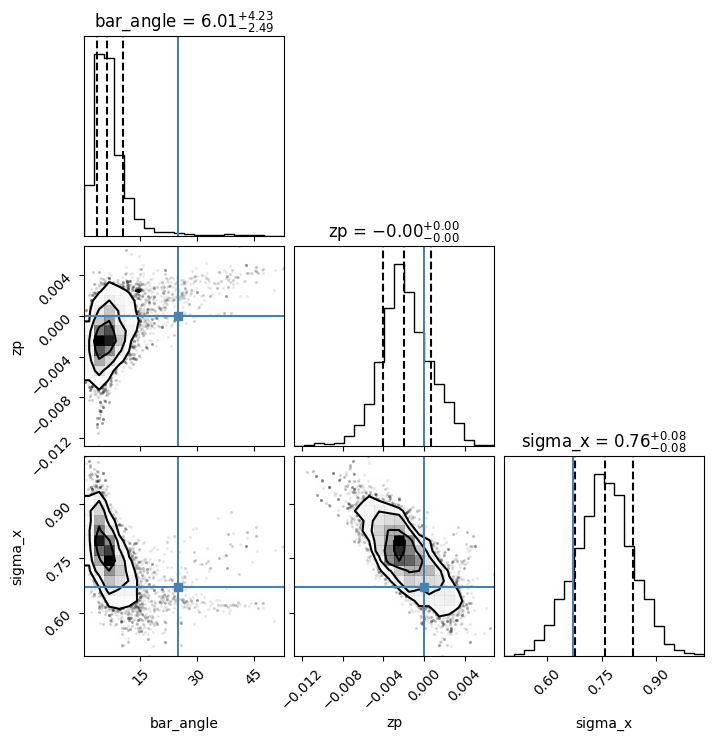

/Users/himanshuverma/Documents/MyHome/MyHomeLSU/Research/Topics/Roman/GaiaBarAngle/Bar-Angle-CalculatorForked/Bar-Angle-Calculator/bar_angle_fitter.py:294: RuntimeWarning: divide by zero encountered in divide
  axsec = ax.secondary_yaxis('right', functions=(lambda x: 1/x, lambda x: 1/x))


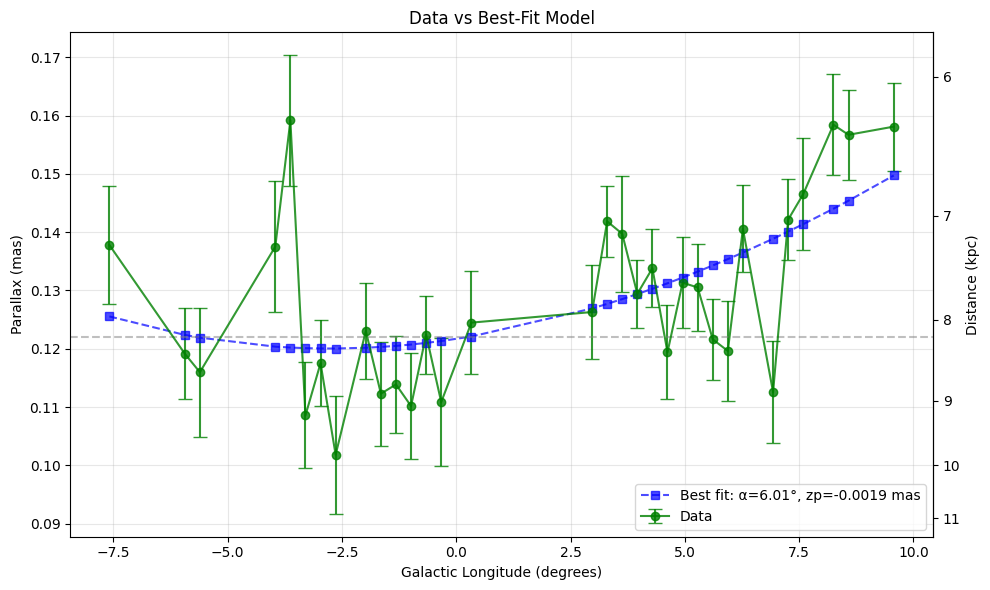

Bar angle: 6.01° $\pm$ 5.35°
Zero-point: -0.0019 $\pm$ 0.0024 mas


In [ ]:
from bar_angle_fitter import BarAngleFitter

model_params = {
    'sigma_x': {'mean': 0.67, 'std': 0.1},  # Gaussian prior
    'sigma_y': 0.29,  # Fixed
    'sigma_z': 0.27,  # Fixed
    'r_E': 8.2,       # Fixed
    's_max': 15.0
}

fitter = BarAngleFitter(
    parallax_data=parallax_data,
    parallax_error=parallax_error,
    l_values=longitude_range,
    b_values=fixed_b_deg,
    model_params=model_params,
    fit_params=['bar_angle', 'zp', 'sigma_x']
)


# Run MCMC
fitter.run_mcmc(n_walkers=6, n_steps=2000, n_burn=100)

# Plot all results (chains, corner plot, fit)
#fitter.plot_results(truths=[fixed_bar_angle, 0.0])
fitter.plot_results()


# Get numerical results
results = fitter.get_results()
print(f"Bar angle: {results['bar_angle']['median']:.2f}° $\\pm$ {results['bar_angle']['std']:.2f}°")
print(f"Zero-point: {results['zp']['median']:.4f} $\\pm$ {results['zp']['std']:.4f} mas")

100%|██████████| 2000/2000 [18:55<00:00,  1.76it/s]


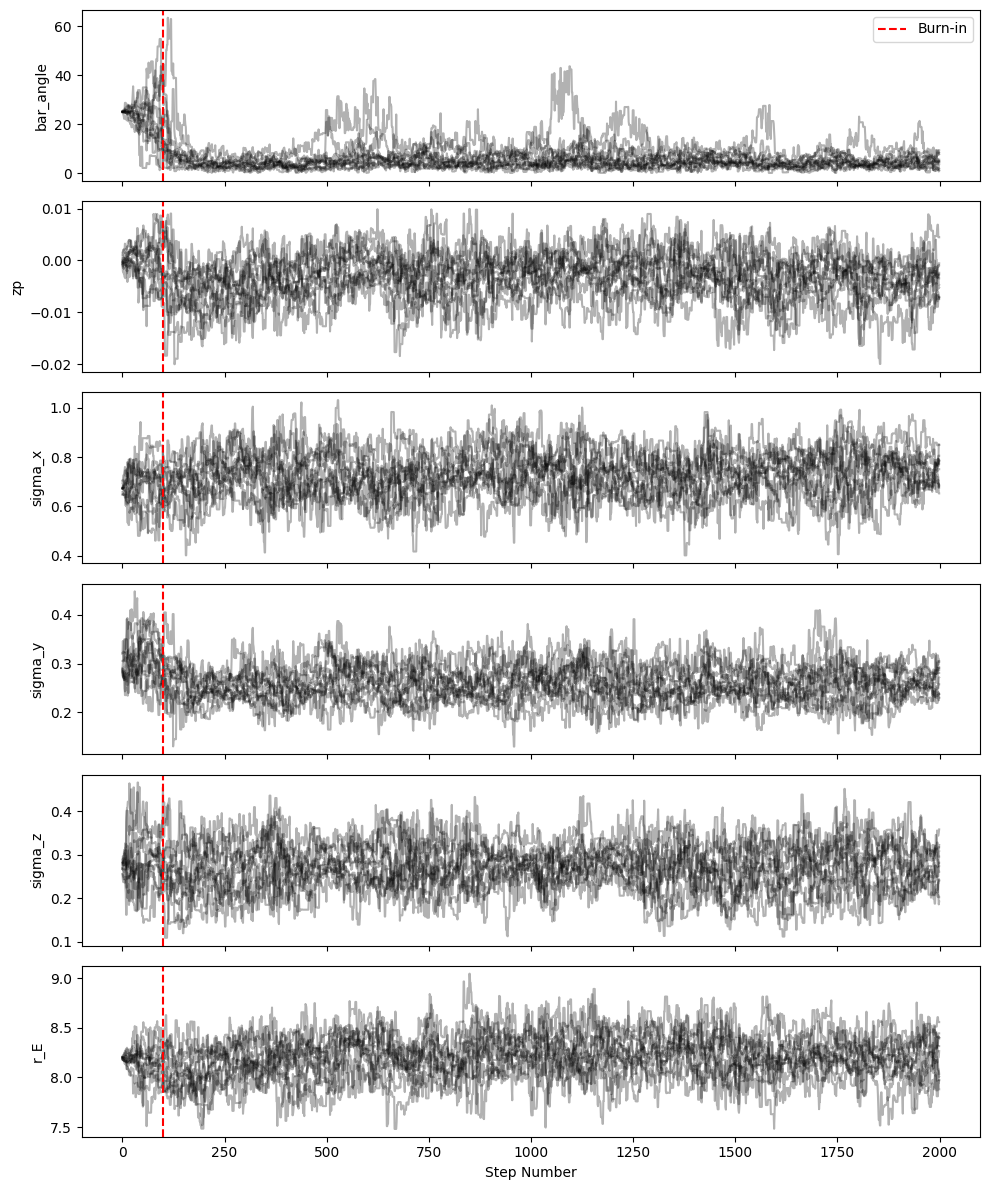

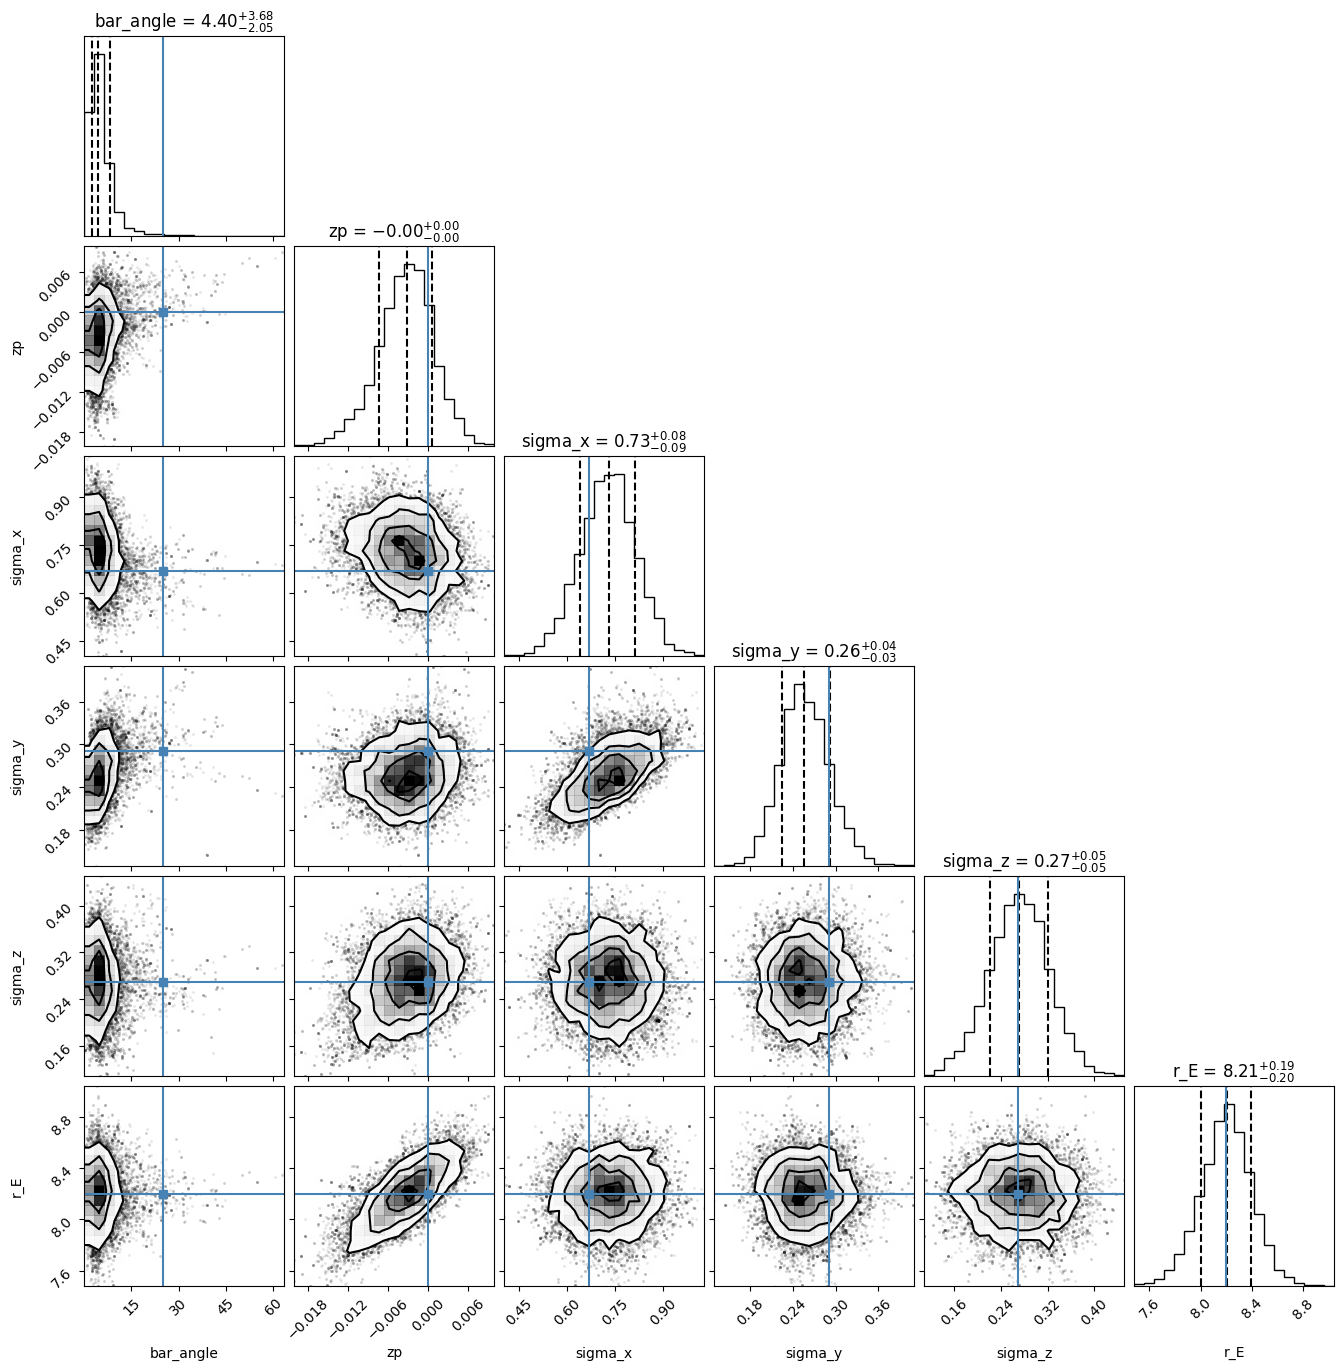

/Users/himanshuverma/Documents/MyHome/MyHomeLSU/Research/Topics/Roman/GaiaBarAngle/Bar-Angle-CalculatorForked/Bar-Angle-Calculator/bar_angle_fitter.py:294: RuntimeWarning: divide by zero encountered in divide
  axsec = ax.secondary_yaxis('right', functions=(lambda x: 1/x, lambda x: 1/x))


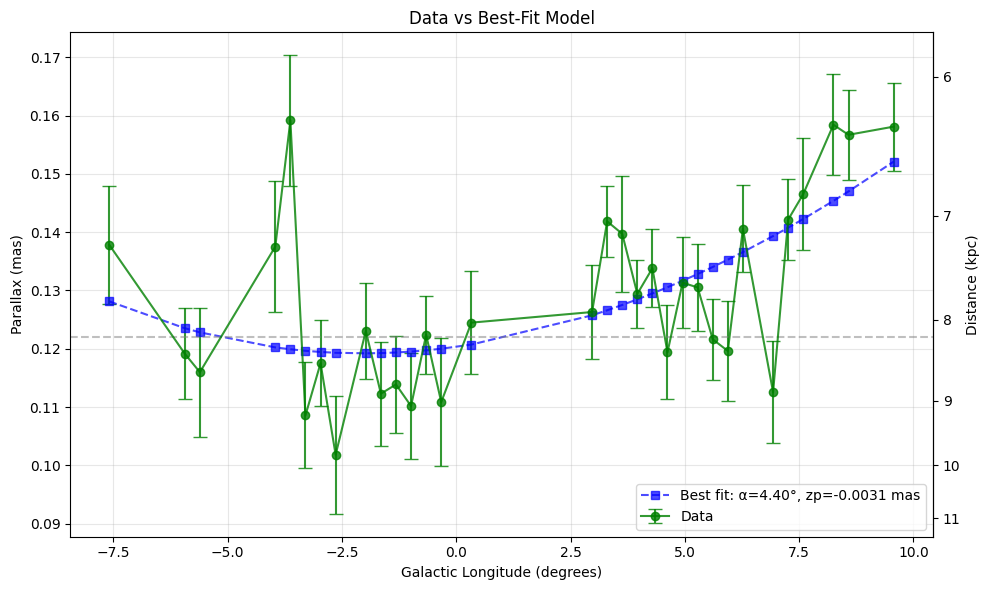

Bar angle: 4.40° $\pm$ 4.42°
Zero-point: -0.0031 $\pm$ 0.0042 mas


In [ ]:
model_params = {
    'sigma_x': {'mean': 0.67, 'std': 0.1},
    'sigma_y': {'mean': 0.29, 'std': 0.05},
    'sigma_z': {'mean': 0.27, 'std': 0.05},
    'r_E': {'mean': 8.2, 'std': 0.2},
    's_max': 15.0  # Always fixed
}

fitter = BarAngleFitter(
    parallax_data=parallax_data,
    parallax_error=parallax_error,
    l_values=longitude_range,
    b_values=fixed_b_deg,
    model_params=model_params,
    fit_params=['bar_angle', 'zp', 'sigma_x', 'sigma_y', 'sigma_z', 'r_E']
)

# Run MCMC
fitter.run_mcmc(n_walkers=12, n_steps=2000, n_burn=100)




# Plot all results (chains, corner plot, fit)

fitter.plot_results(truths=[25.0, 0.0, 0.67, 0.29, 0.27, 8.2])
# Get numerical results
results = fitter.get_results()
print(f"Bar angle: {results['bar_angle']['median']:.2f}° $\\pm$ {results['bar_angle']['std']:.2f}°")
print(f"Zero-point: {results['zp']['median']:.4f} $\\pm$ {results['zp']['std']:.4f} mas")

100%|██████████| 2000/2000 [15:59<00:00,  2.08it/s]


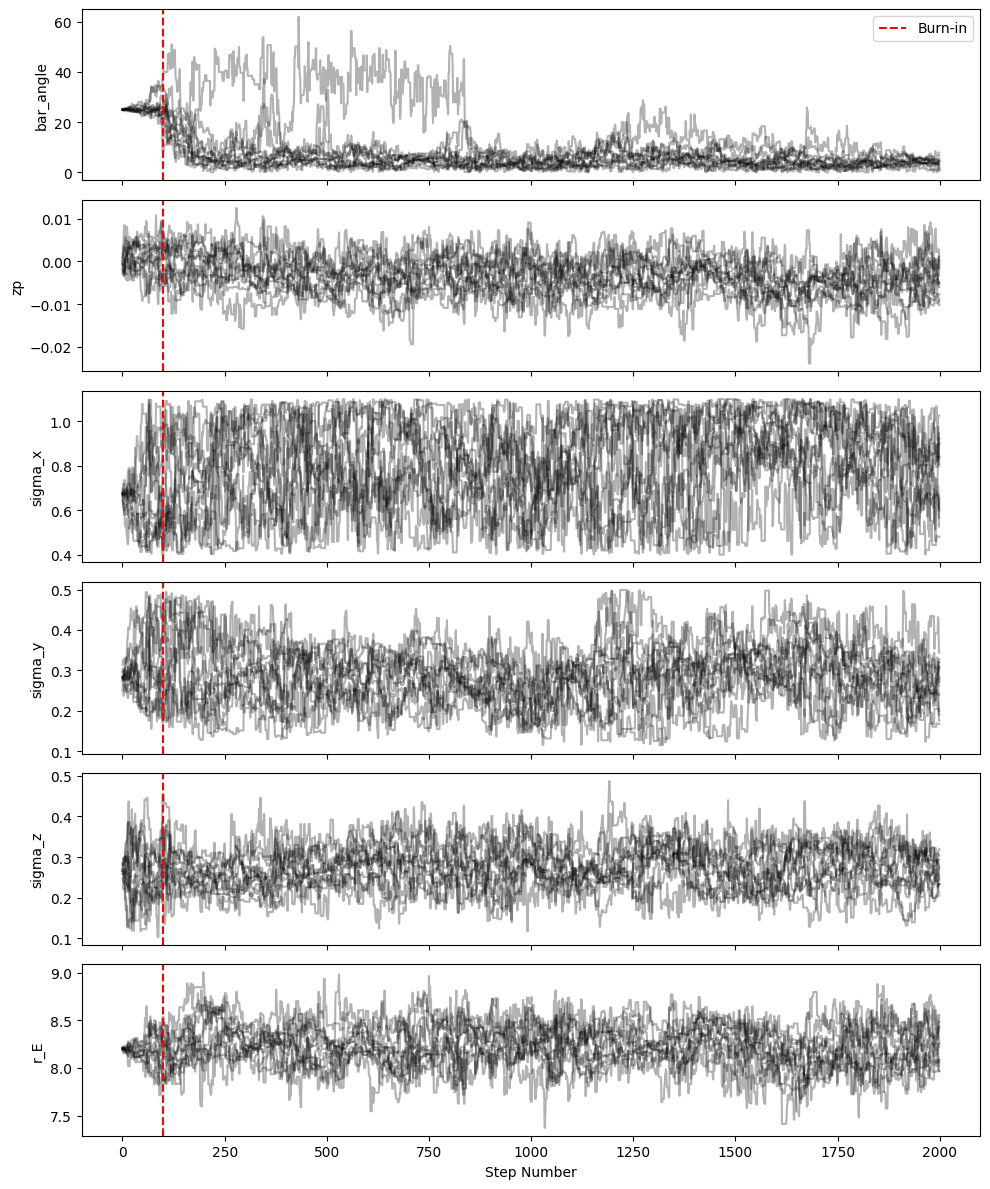

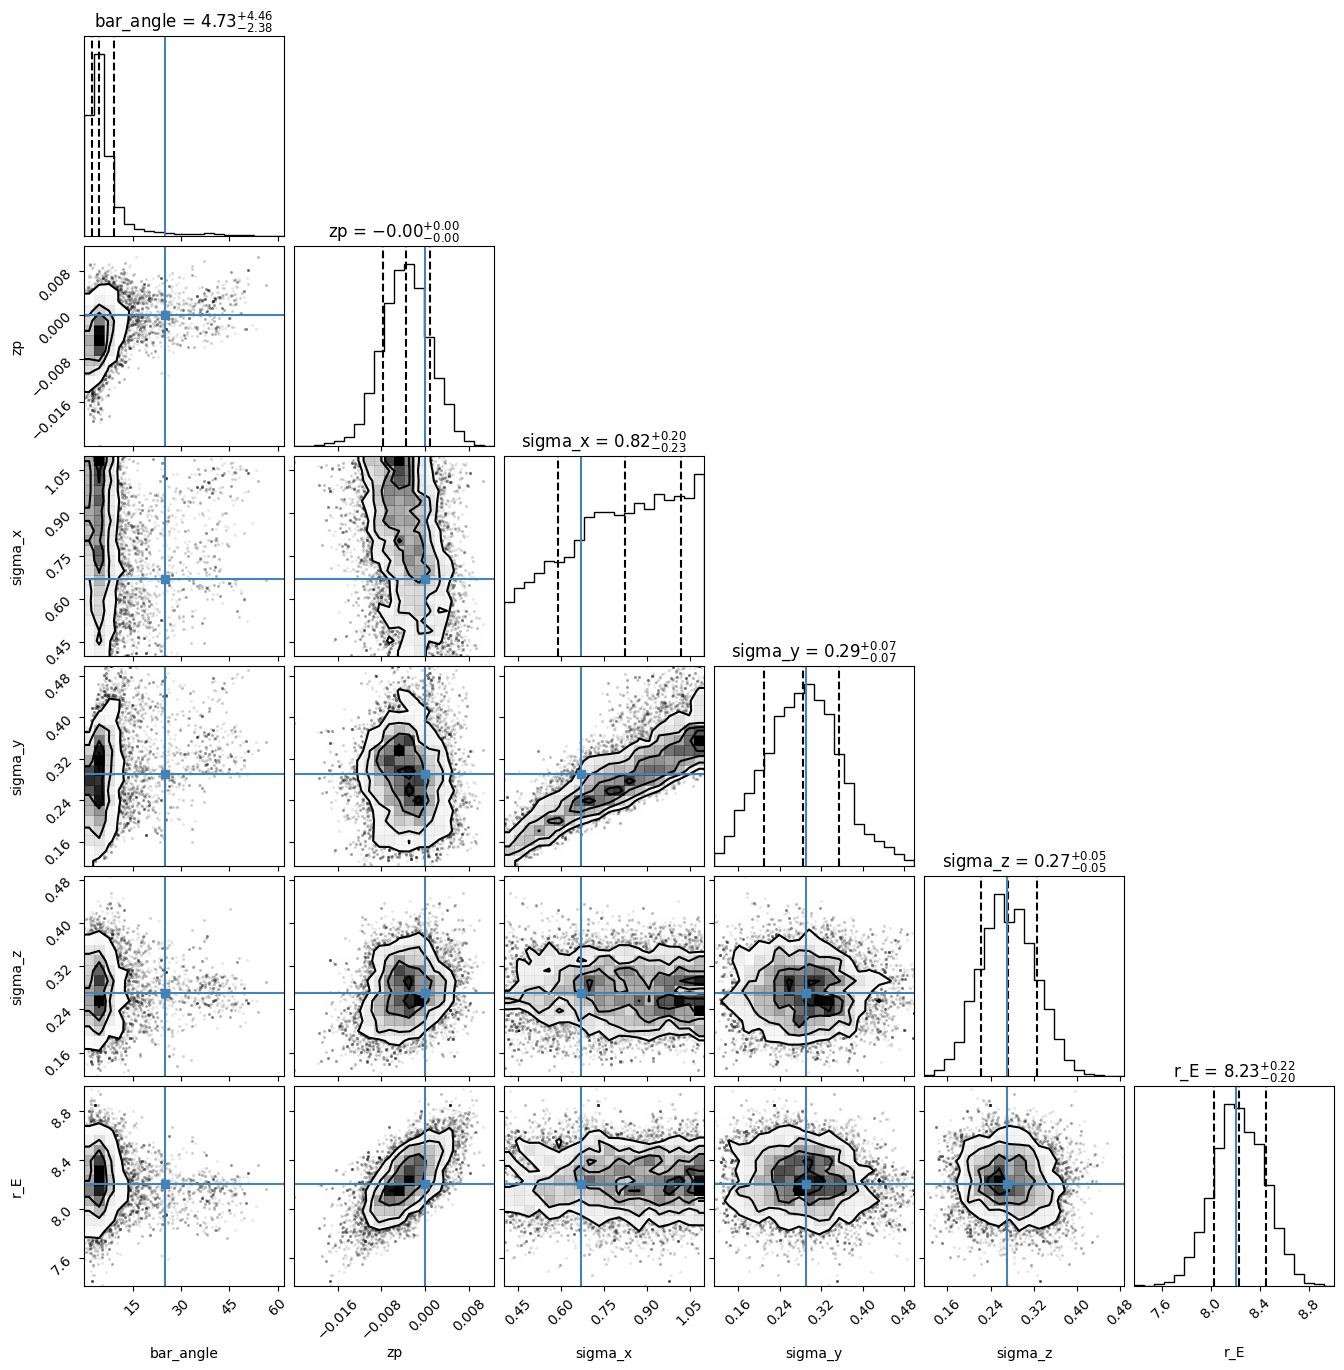

/Users/himanshuverma/Documents/MyHome/MyHomeLSU/Research/Topics/Roman/GaiaBarAngle/Bar-Angle-CalculatorForked/Bar-Angle-Calculator/bar_angle_fitter.py:294: RuntimeWarning: divide by zero encountered in divide
  axsec = ax.secondary_yaxis('right', functions=(lambda x: 1/x, lambda x: 1/x))


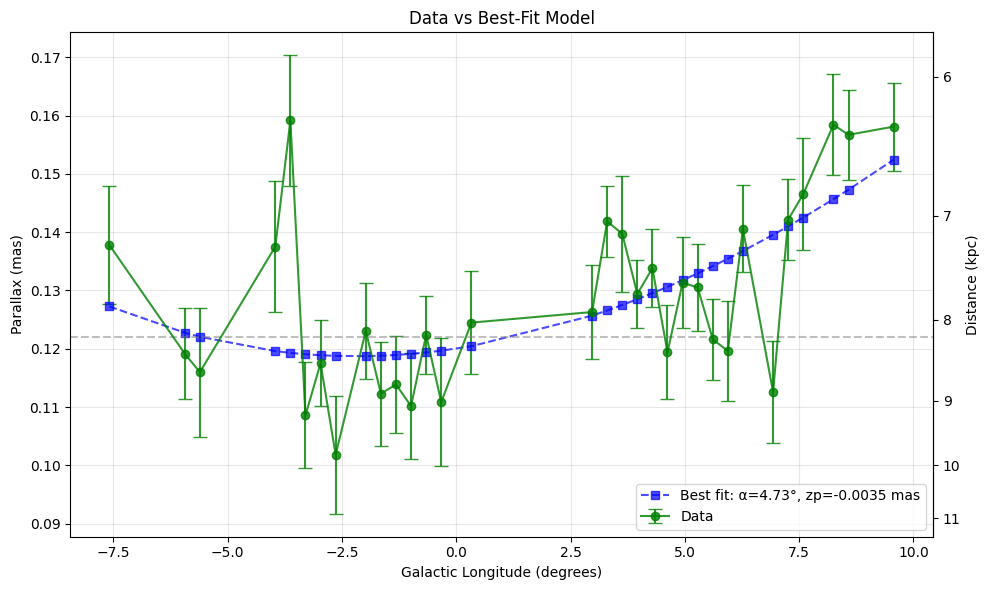

Bar angle: 4.73° $\pm$ 6.97°
Zero-point: -0.0035 $\pm$ 0.0043 mas


In [28]:
from bar_angle_fitter import BarAngleFitter

model_params = {
    'sigma_x': 0.67,
    'sigma_y': 0.29,
    'sigma_z': {'mean': 0.27, 'std': 0.05},
    'r_E': {'mean': 8.2, 'std': 0.2},
    's_max': 15.0  # Always fixed
}

fitter = BarAngleFitter(
    parallax_data=parallax_data,
    parallax_error=parallax_error,
    l_values=longitude_range,
    b_values=fixed_b_deg,
    model_params=model_params,
    fit_params=['bar_angle', 'zp', 'sigma_x', 'sigma_y', 'sigma_z', 'r_E']
)

# Run MCMC
fitter.run_mcmc(n_walkers=12, n_steps=2000, n_burn=100, priors_range={'sigma_x': (0.4, 1.1), 'sigma_y': (0.1, 0.5)})

# Plot all results (chains, corner plot, fit)

fitter.plot_results(truths=[25.0, 0.0, 0.67, 0.29, 0.27, 8.2])
# Get numerical results
results = fitter.get_results()
print(f"Bar angle: {results['bar_angle']['median']:.2f}° $\\pm$ {results['bar_angle']['std']:.2f}°")
print(f"Zero-point: {results['zp']['median']:.4f} $\\pm$ {results['zp']['std']:.4f} mas")

100%|██████████| 2000/2000 [2:13:31<00:00,  4.01s/it]  


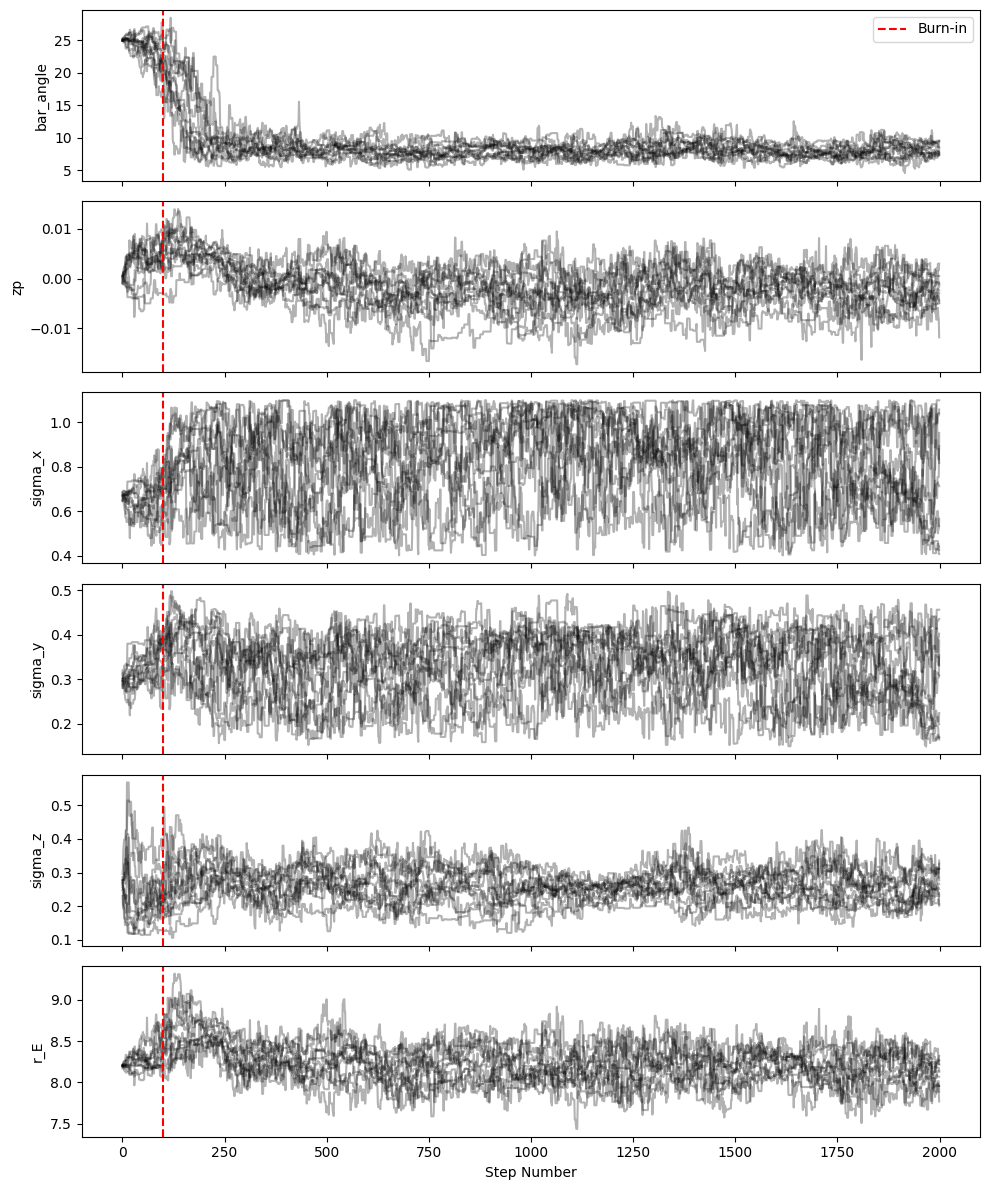

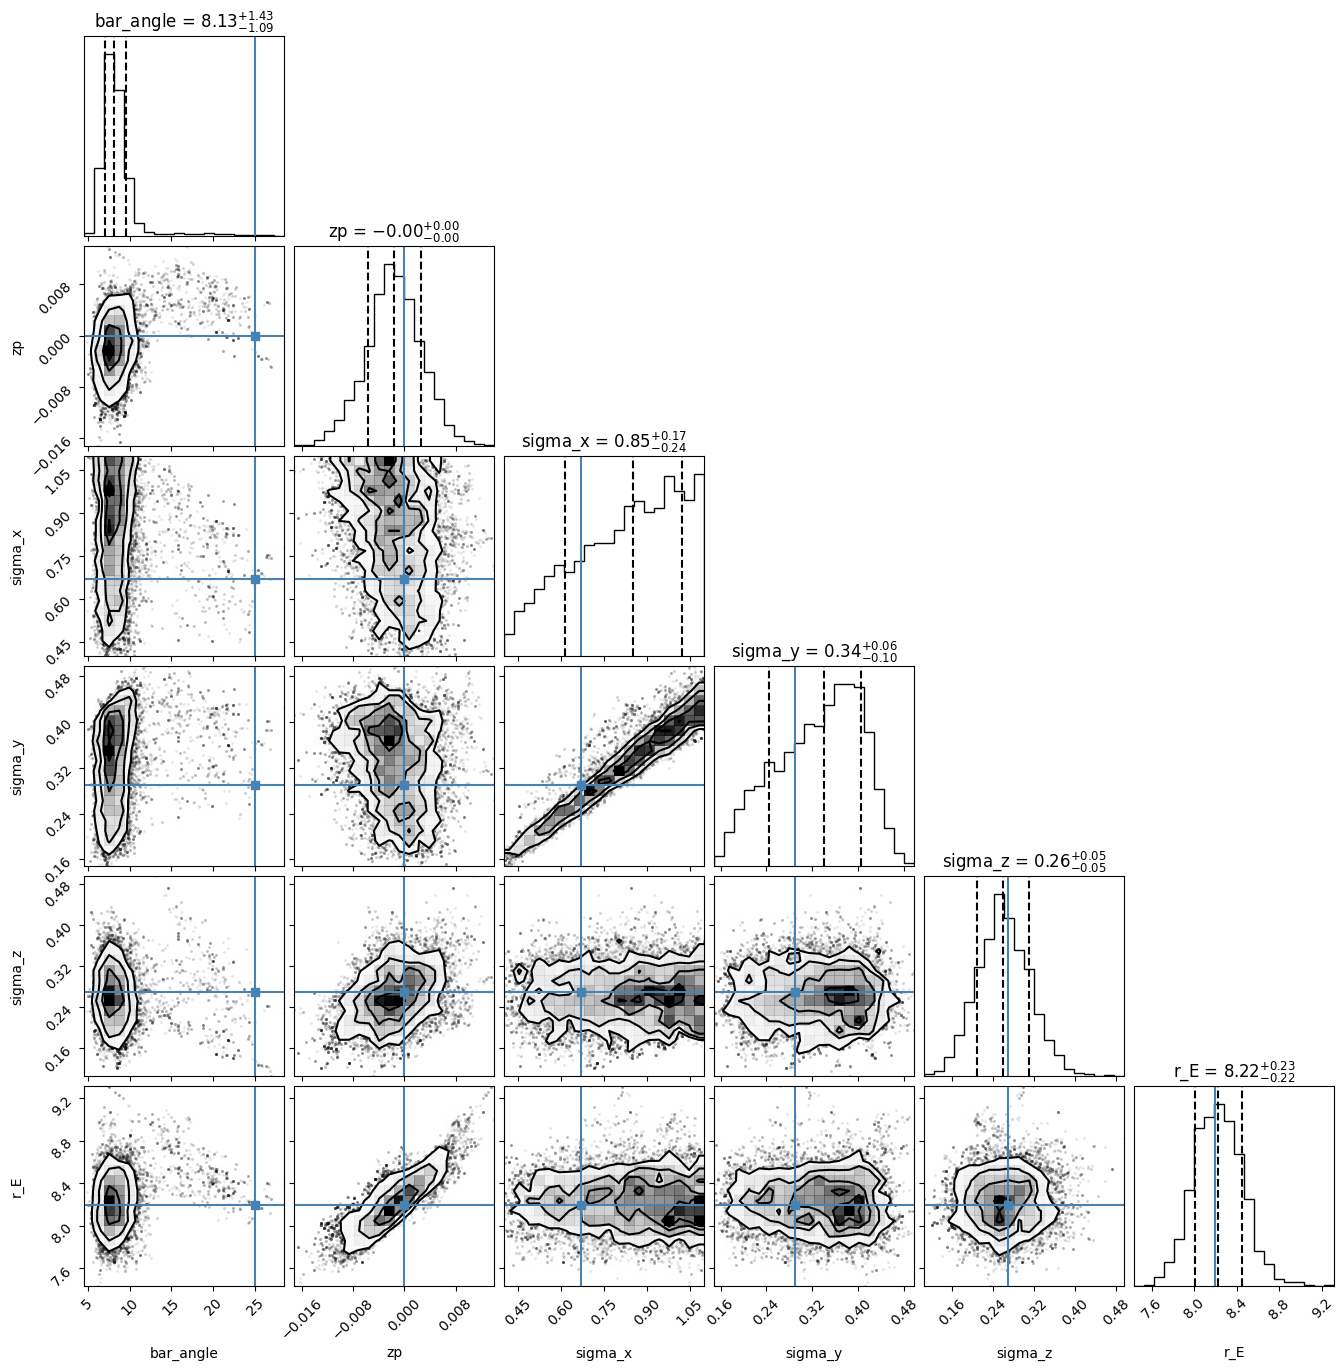

/Users/himanshuverma/Documents/MyHome/MyHomeLSU/Research/Topics/Roman/GaiaBarAngle/Bar-Angle-CalculatorForked/Bar-Angle-Calculator/bar_angle_fitter.py:294: RuntimeWarning: divide by zero encountered in divide
  axsec = ax.secondary_yaxis('right', functions=(lambda x: 1/x, lambda x: 1/x))


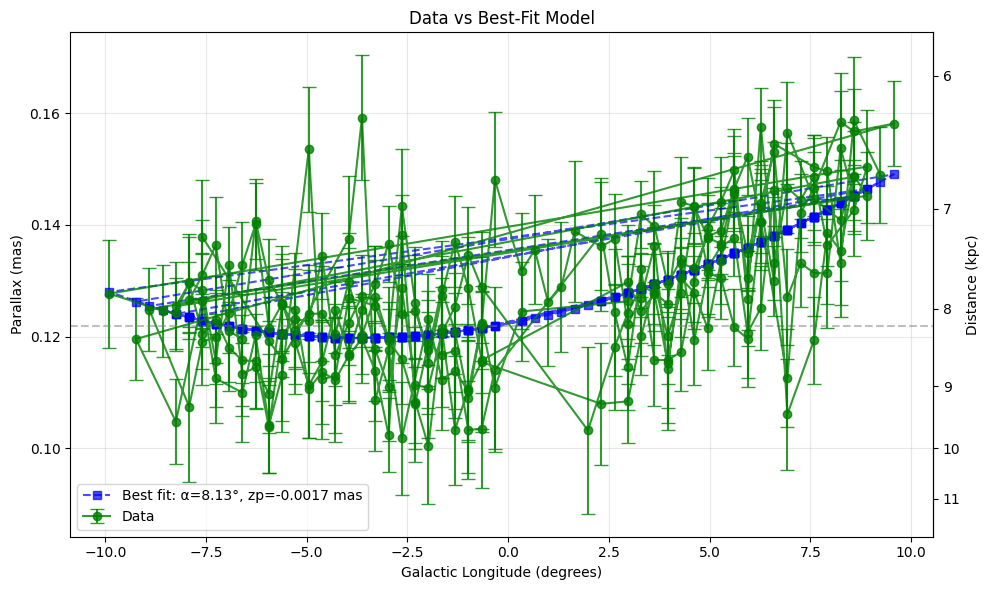

Bar angle: 8.13° $\pm$ 2.45°
Zero-point: -0.0017 $\pm$ 0.0043 mas


In [30]:
from bar_angle_fitter import BarAngleFitter

model_params = {
    'sigma_x': 0.67,
    'sigma_y': 0.29,
    'sigma_z': {'mean': 0.27, 'std': 0.05},
    'r_E': {'mean': 8.2, 'std': 0.2},
    's_max': 15.0  # Always fixed
}

longitude_range = df_u['Long']
parallax_data = df_u['Mean Parallax']
parallax_error = df_u['Mean Parallax Error']


fitter = BarAngleFitter(
    parallax_data=parallax_data,
    parallax_error=parallax_error,
    l_values=longitude_range,
    b_values=fixed_b_deg,
    model_params=model_params,
    fit_params=['bar_angle', 'zp', 'sigma_x', 'sigma_y', 'sigma_z', 'r_E']
)

# Run MCMC
fitter.run_mcmc(n_walkers=12, n_steps=2000, n_burn=100, priors_range={'sigma_x': (0.4, 1.1), 'sigma_y': (0.1, 0.5)})

# Plot all results (chains, corner plot, fit)

fitter.plot_results(truths=[25.0, 0.0, 0.67, 0.29, 0.27, 8.2])
# Get numerical results
results = fitter.get_results()
print(f"Bar angle: {results['bar_angle']['median']:.2f}° $\\pm$ {results['bar_angle']['std']:.2f}°")
print(f"Zero-point: {results['zp']['median']:.4f} $\\pm$ {results['zp']['std']:.4f} mas")

100%|██████████| 2000/2000 [13:41<00:00,  2.44it/s]


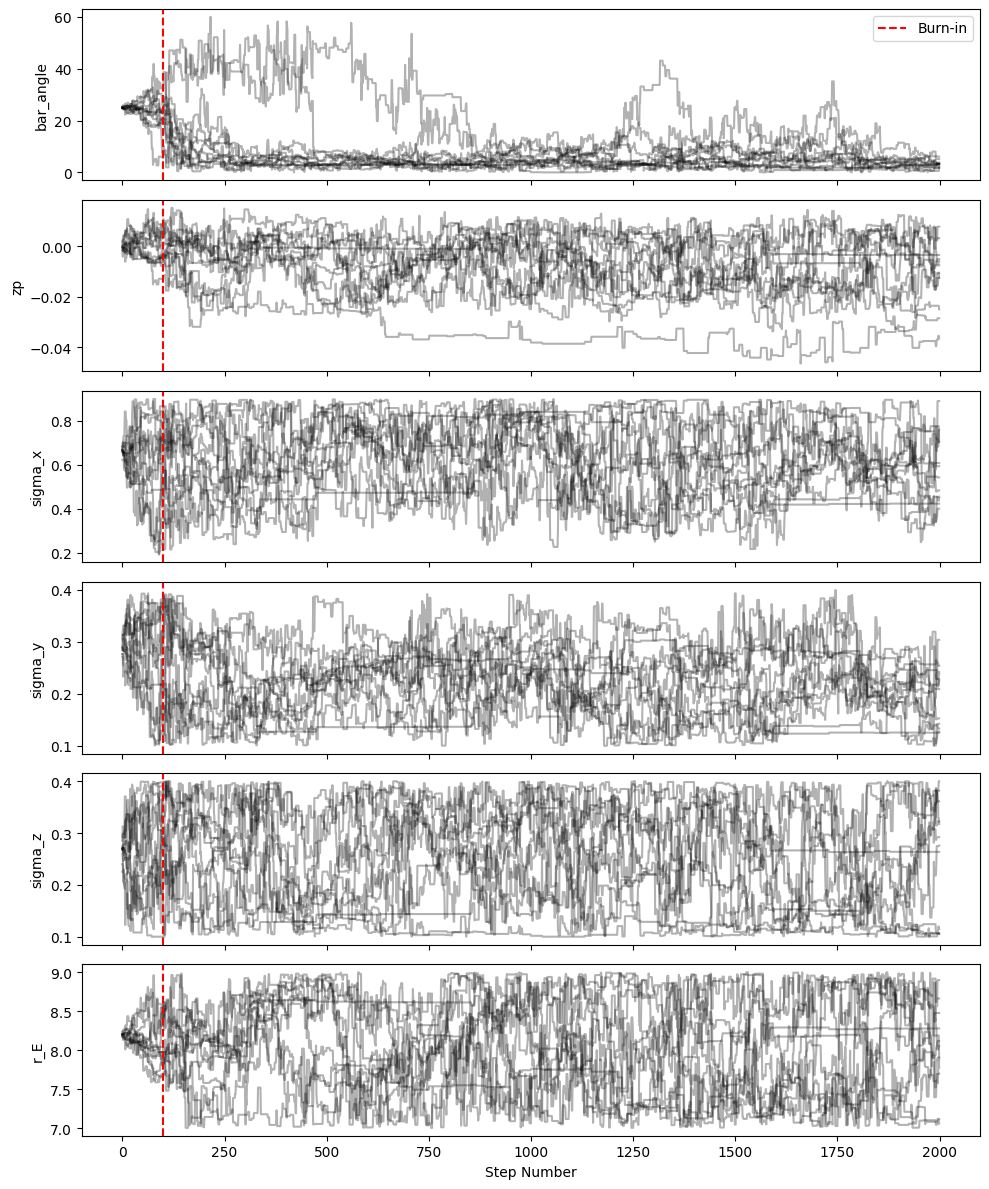

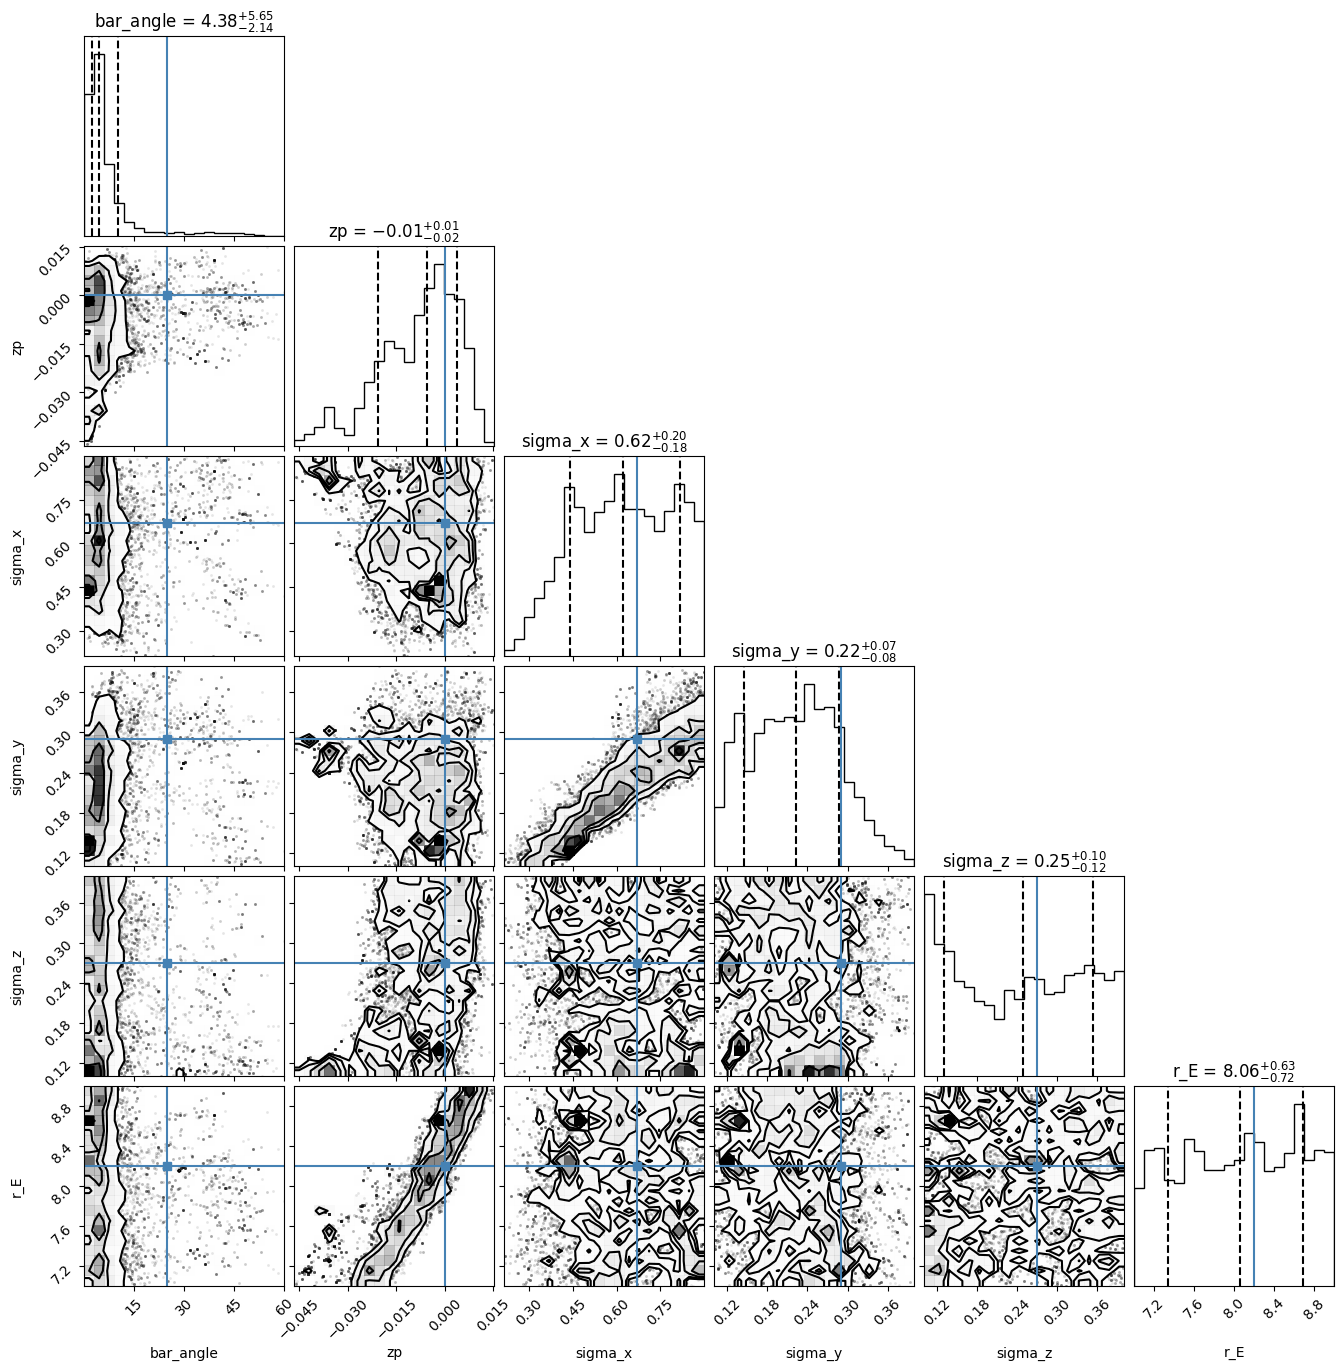

/Users/himanshuverma/Documents/MyHome/MyHomeLSU/Research/Topics/Roman/GaiaBarAngle/Bar-Angle-CalculatorForked/Bar-Angle-Calculator/bar_angle_fitter.py:294: RuntimeWarning: divide by zero encountered in divide
  axsec = ax.secondary_yaxis('right', functions=(lambda x: 1/x, lambda x: 1/x))


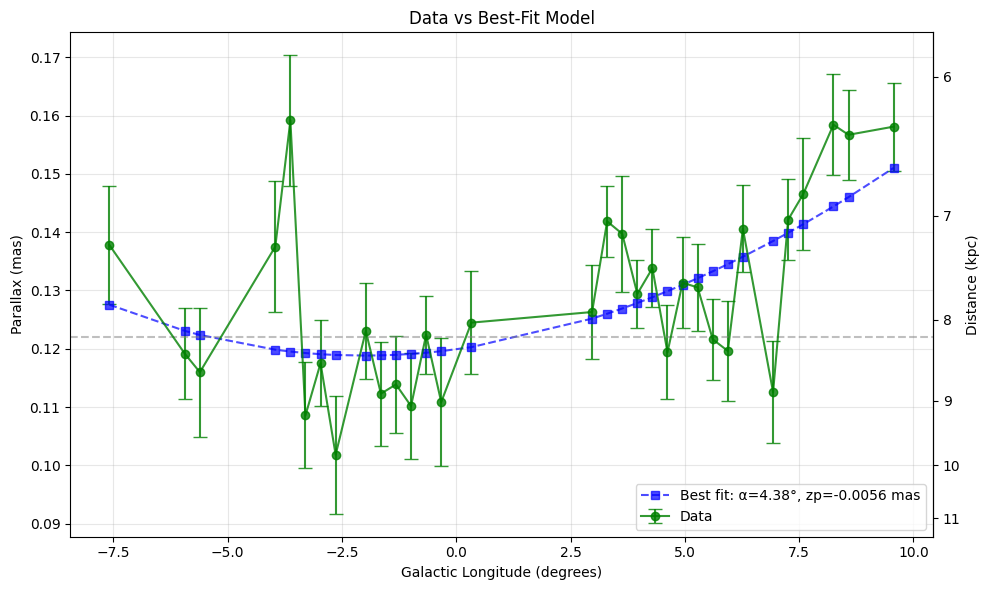

Bar angle: 4.38° $\pm$ 8.67°
Zero-point: -0.0056 $\pm$ 0.0122 mas


In [29]:
from bar_angle_fitter import BarAngleFitter

model_params = {
    'sigma_x': 0.67,
    'sigma_y': 0.29,
    'sigma_z': 0.27,
    'r_E': 8.2,
    's_max': 15.0  # Always fixed
}

fitter = BarAngleFitter(
    parallax_data=parallax_data,
    parallax_error=parallax_error,
    l_values=longitude_range,
    b_values=fixed_b_deg,
    model_params=model_params,
    fit_params=['bar_angle', 'zp', 'sigma_x', 'sigma_y', 'sigma_z', 'r_E']
)

# Run MCMC
fitter.run_mcmc(n_walkers=12, n_steps=2000, n_burn=100, priors_range={'sigma_x': (0.1, 0.9), 'sigma_y': (0.1, 0.4), 'sigma_z': (0.1, 0.4), 'r_E': (7, 9)})

# Plot all results (chains, corner plot, fit)

fitter.plot_results(truths=[25.0, 0.0, 0.67, 0.29, 0.27, 8.2])
# Get numerical results
results = fitter.get_results()
print(f"Bar angle: {results['bar_angle']['median']:.2f}° $\\pm$ {results['bar_angle']['std']:.2f}°")
print(f"Zero-point: {results['zp']['median']:.4f} $\\pm$ {results['zp']['std']:.4f} mas")

# to do
- No prior run
- Running with prior on rE, sigma_z
- Run with priors on sigma_x, sigma_y, sigma_z, rE


- Running with individual strips (i.e. b=fixed)
    - No prior run
    - Running with prior on rE, sigma_z
    - Run with priors on sigma_x, sigma_y, sigma_z, rE

- Run with all combination of (l,b) with sigma_z free

- Origin of correlation needs to be explained/examined



- Running with all combination of (l,b)
    - No prior run
    - Running with prior on rE, sigma_z
    - Run with priors on sigma_x, sigma_y, sigma_z, rE


- Store chi2 and dof for each run
- Maybe store chains and then derive 
    - Compute covariance matrix of the parameters as well.
    - best fit
